# EDA

## Data preparation
- importing libraries
- creating paths to files with raw and processed data
- loading data

In [2]:
import pandas as pd
from pathlib import Path

base_dir = Path.cwd().parent
raw_data_path = base_dir / "data" / "raw" / "predictive_maintenance.csv"
processed_data_path = base_dir / "data" / "processed" / "features.csv"

df = pd.read_csv(raw_data_path).set_index("UDI")

## Descriptive statistics

### Features
Machines have 6 features: Type, Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min]

In [3]:
print(df.head())

    Product ID Type  Air temperature [K]  Process temperature [K]  \
UDI                                                                 
1       M14860    M                298.1                    308.6   
2       L47181    L                298.2                    308.7   
3       L47182    L                298.1                    308.5   
4       L47183    L                298.2                    308.6   
5       L47184    L                298.2                    308.7   

     Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
UDI                                                                             
1                      1551         42.8                0       0   No Failure  
2                      1408         46.3                3       0   No Failure  
3                      1498         49.4                5       0   No Failure  
4                      1433         39.5                7       0   No Failure  
5                      1408   

### Missing data
Dataset has no missing data

In [8]:
print(df.isnull().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64


### Target/Failures
- The dataset is unbalanced, with only 339 failures per 10,000 records. This could negatively impact model learning.
- Individual types of failures are also unbalanced

In [9]:
print(df['Target'].sum())

print("\n")

print(df['Failure Type'].value_counts())

339


Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


### Data spread
- Temperatures (Air & Process): These have a very small standard deviation (2.00 K and 1.48 K). This suggests that thermal conditions are very stable and predictable.
- Torque: The deviation is approximately 9.97 Nm, with an average of approximately 40 Nm. This is quite significant variability (approximately 25%), suggesting that the machine load fluctuates quite significantly.
- Tool wear: The average is 107.9 min, with a variance of 63.6 min. This suggests that the tools are in very different conditions – from almost new to completely worn.

In [29]:
print("Standard deviation:")
print(df[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']].std())

print("\nVariances:")
print(df[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']].var())

Standard deviation:
Air temperature [K]          2.000259
Process temperature [K]      1.483734
Rotational speed [rpm]     179.284096
Torque [Nm]                  9.968934
Tool wear [min]             63.654147
dtype: float64

Variances:
Air temperature [K]            4.001035
Process temperature [K]        2.201467
Rotational speed [rpm]     32142.787047
Torque [Nm]                   99.379640
Tool wear [min]             4051.850384
dtype: float64


### Indicators of distribution shape
- Air Temperature, Process Temperature, and Torque: Their skewness is close to 0 and kurtosis is low. This means that their distributions are quite symmetrical and "calm."
- Rotational speed:
  - Skewness (1.99): This is clearly positive. This indicates a "right-skewed" bias—meaning there are many low-speed results and a "long tail" of rare, very high values.
  - Kurtosis (7.39): This is very high (leptokurtic distribution). This means the data is strongly concentrated around the mean but has very extreme outliers.

In [28]:
print("Skewness")
print(df[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']].skew())

print("\nKurtosis")
print(df[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']].kurtosis())

Skewness
Air temperature [K]        0.114274
Process temperature [K]    0.015027
Rotational speed [rpm]     1.993171
Torque [Nm]               -0.009517
Tool wear [min]            0.027292
dtype: float64

Kurtosis
Air temperature [K]       -0.835962
Process temperature [K]   -0.499734
Rotational speed [rpm]     7.392945
Torque [Nm]               -0.013241
Tool wear [min]           -1.166737
dtype: float64


### Central Tendency
- Temperatures (Air & Process) and Torque: The distribution is symmetrical. The process in these areas is stable, with no unusual spikes, and the machine operates under predictable conditions.
- Tool wear: The dataset is well balanced in terms of hardware usage.
- Rotational speed: The average exceeds the median by approximately 35 rpm, confirming a strong right-sided skew and the presence of outliers in the upper rpm registers.

In [31]:
print("Mean:")
print(df[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']].mean())

print("\nMedian:")
print(df[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']].median())

Mean:
Air temperature [K]         300.00493
Process temperature [K]     310.00556
Rotational speed [rpm]     1538.77610
Torque [Nm]                  39.98691
Tool wear [min]             107.95100
dtype: float64

Median:
Air temperature [K]         300.1
Process temperature [K]     310.1
Rotational speed [rpm]     1503.0
Torque [Nm]                  40.1
Tool wear [min]             108.0
dtype: float64


### Histograms
The visualization confirms the statistical analysis: the temperature and torque distributions are close to normal, while rotational speed exhibits a right-hand skew with significant outliers. The tool wear distribution is nearly uniform, indicating completeness of the data over the full tool life cycle.

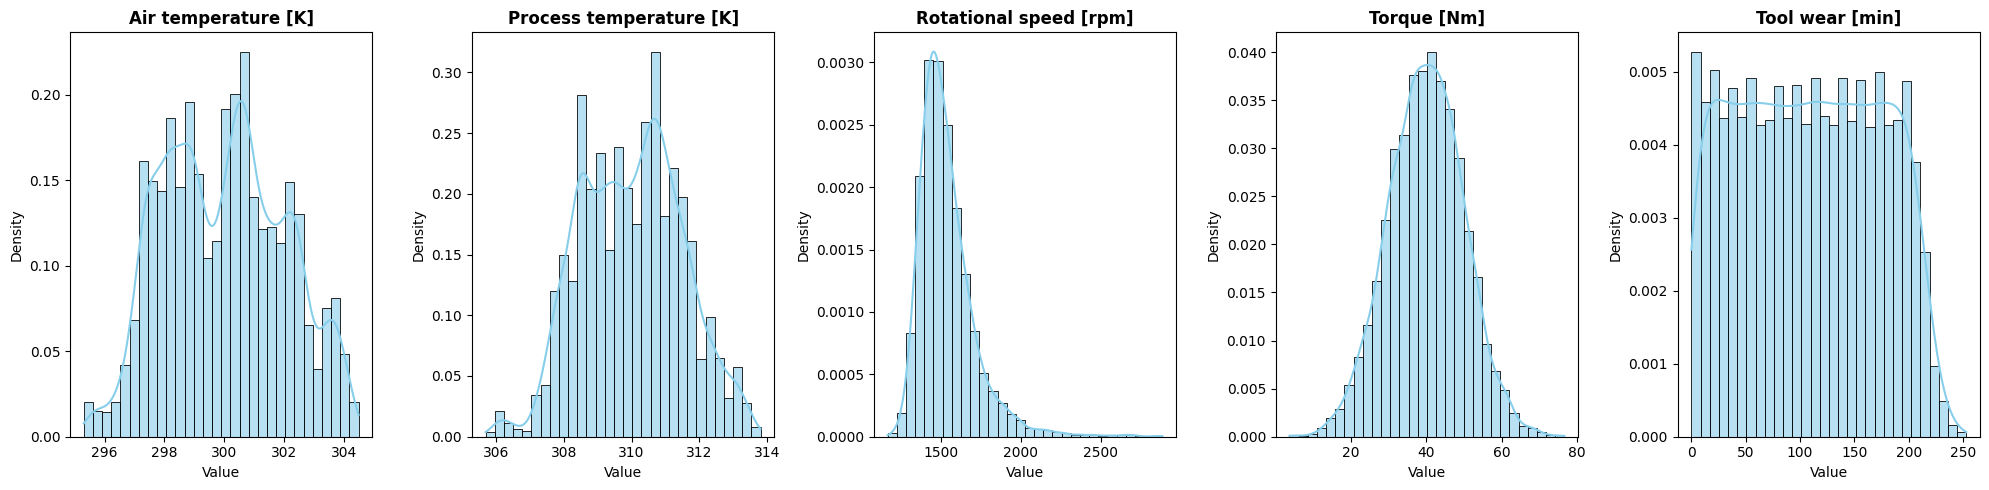

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

columns = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

for ax, col in zip(axes, columns):
    sns.histplot(df[col], bins=30, kde=True, stat="density", ax=ax, 
                 color='skyblue', edgecolor='black', alpha=0.6)
    
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    

plt.tight_layout()
plt.show()

### Boxplots
- Rotational speed: Because the dots are only at the top, the machine never slows down abnormally, but it often "speeds up" beyond its safe range. These dots are ideal candidates for failure modes (overheating or breakage).
- Torque: Outliers are above 70 Nm and below 15 Nm. This can suggest two types of problems: excessive load (upper dots) or, for example, idling/belt breakage (lower dots).
- Temperatures (Air & Process): No dots. Clean boxes. This confirms that the thermal environment is fully controlled. No sudden bursts of heat or cold.
- Tool wear: There are no dots and very long "whiskers." This confirms a uniform distribution. The tool simply wears out linearly from 0 to 250 minutes, with each state having the same probability.

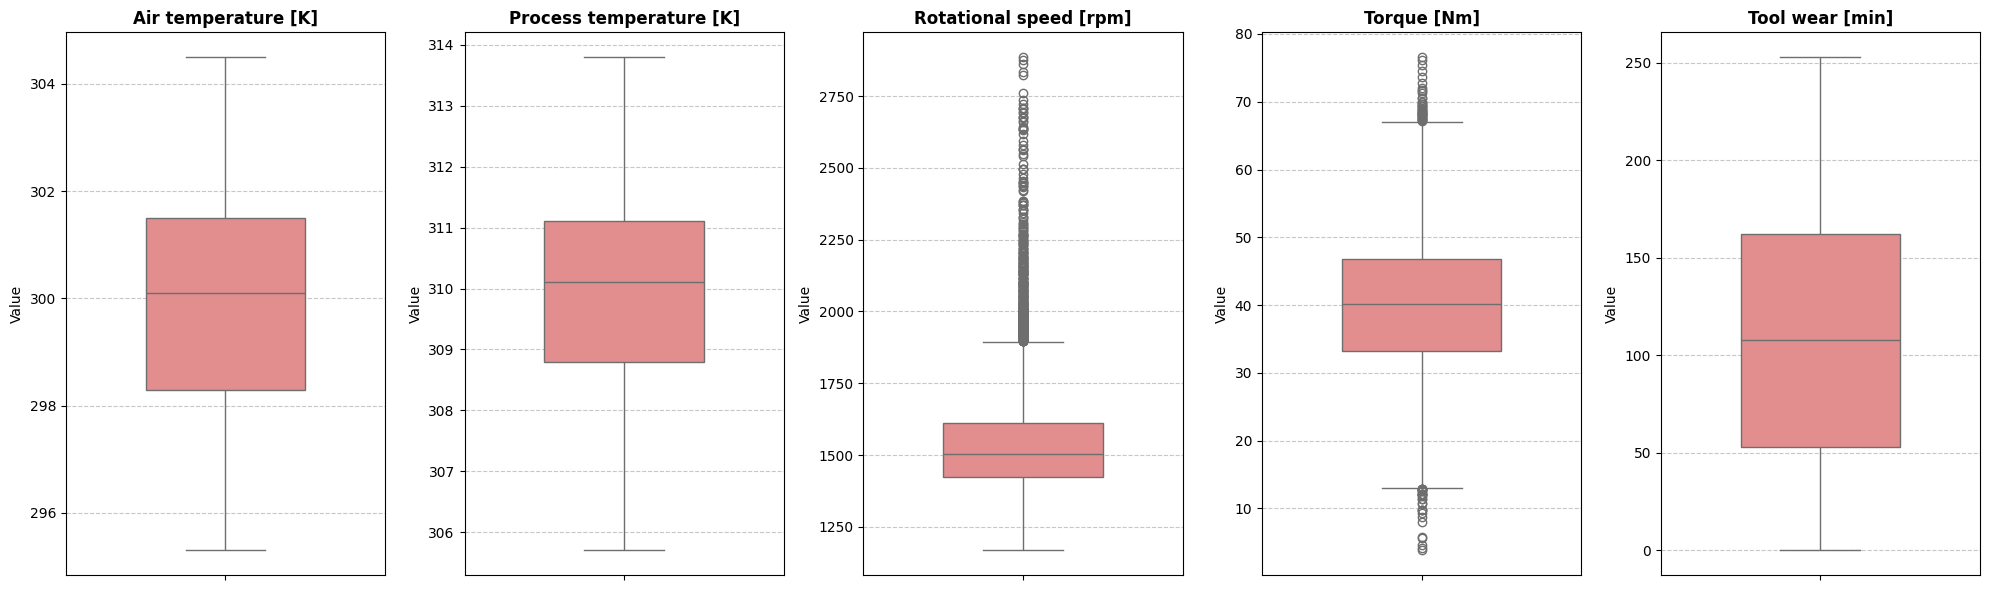

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

columns = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

for ax, col in zip(axes, columns):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral', width=0.5)
    
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Heatmap
- Strong positive correlation between Air temperature and Process temperature
- A very strong negative correlation. Two variables carry almost the same information, but from two different directions.
- Tool wear has zero correlation with current temperature or speed. This means that the tool wears out regardless of how intensely the machine is operating at any given time (it likely simply wears out linearly over time).

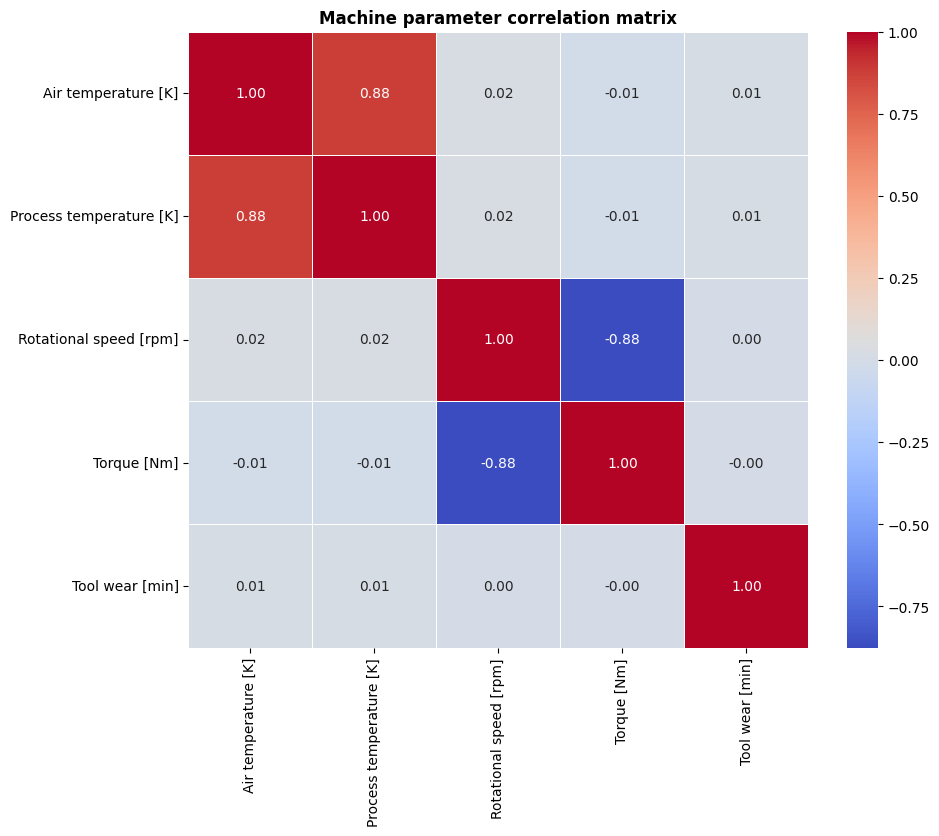

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df[['Air temperature [K]', 'Process temperature [K]', 
                 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Machine parameter correlation matrix', fontweight='bold')
plt.show()

### Average parameters for each type of failure
- Power failures are strongly correlated with high rotational speed.
- Overstrain occurs when high torque and advanced tool wear are combined.
- Tool wear failure is predictable and occurs after a threshold of approximately 200 minutes of operation. 

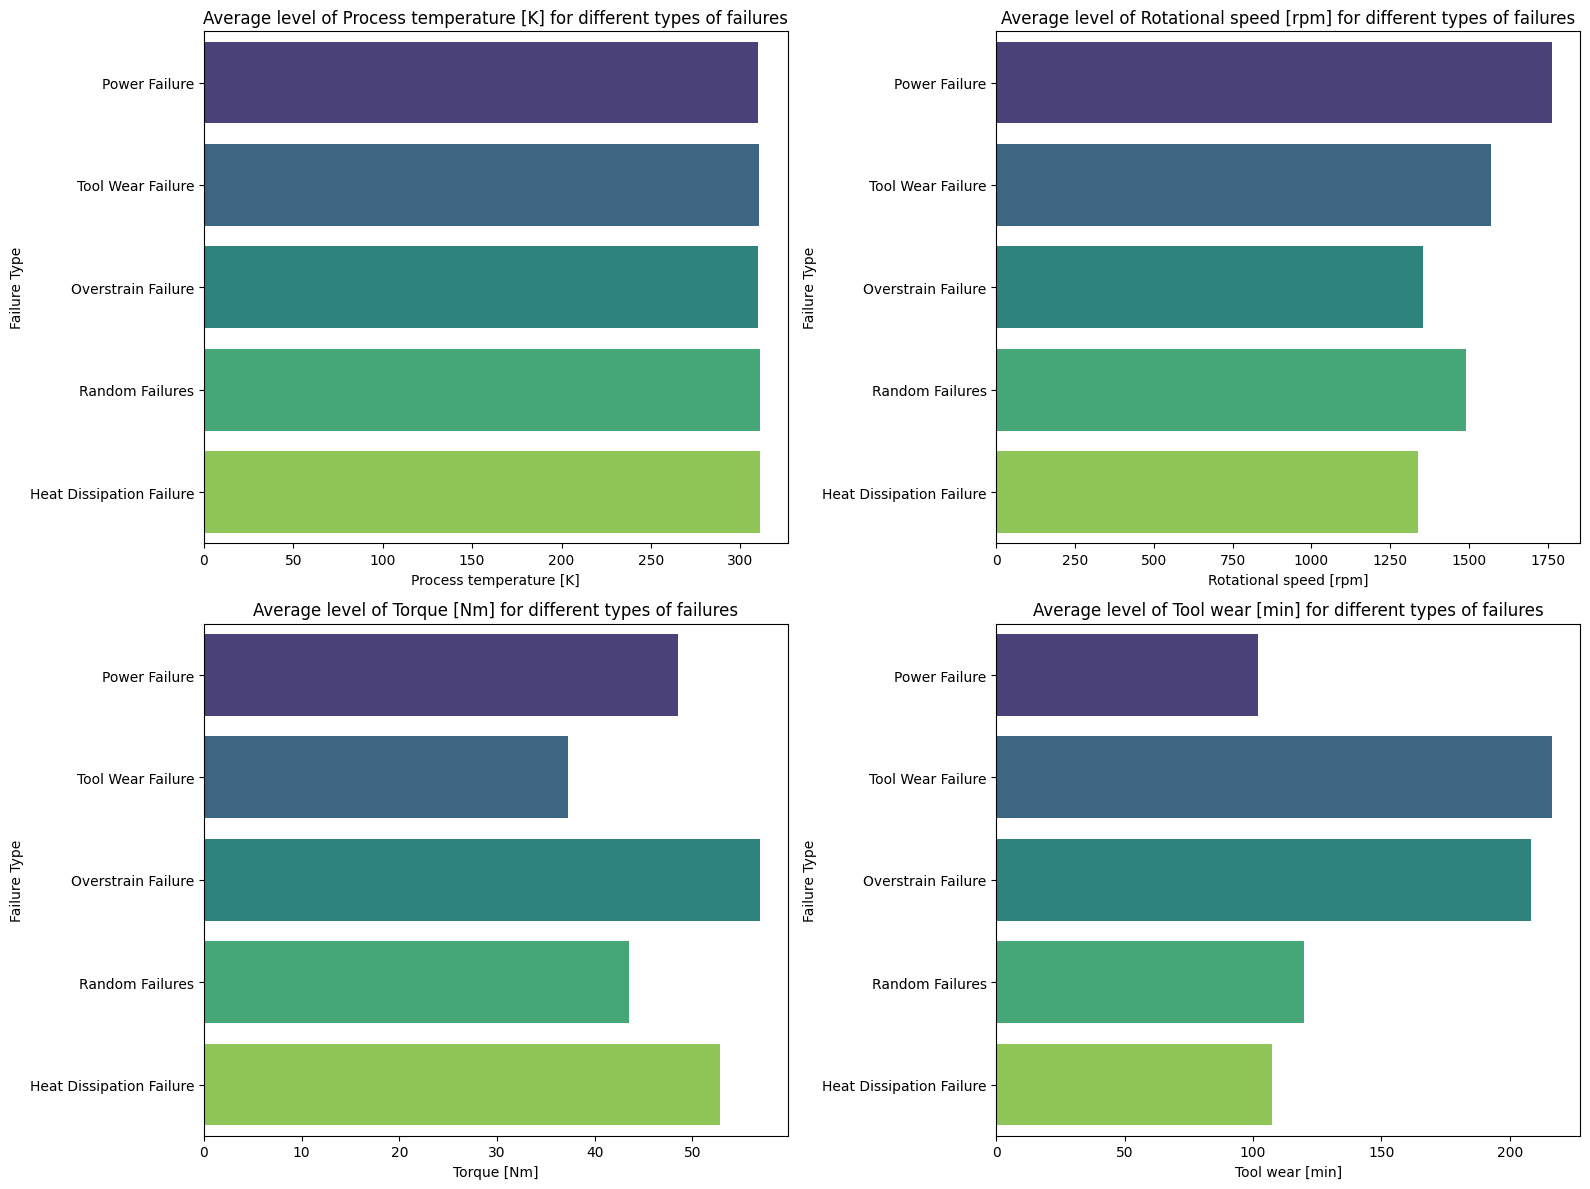

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df_failures = df[df['Failure Type'] != 'No Failure']

cols_to_check = ['Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols_to_check):
    sns.barplot(x=col, y='Failure Type', data=df_failures, ax=ax, 
            palette='viridis', hue='Failure Type', legend=False, errorbar=None)
    ax.set_title(f'Average level of {col} for different types of failures')

plt.tight_layout()
plt.show()

### Type variable
Analysis of the Type variable revealed that the set is unbalanced not only in terms of failures but also in terms of device class. Type L machines constitute the majority of the set and have the highest failure rate. This suggests that the quality of a machine's construction (its class) is a significant factor in its lifetime, which should be considered in the machine learning process.

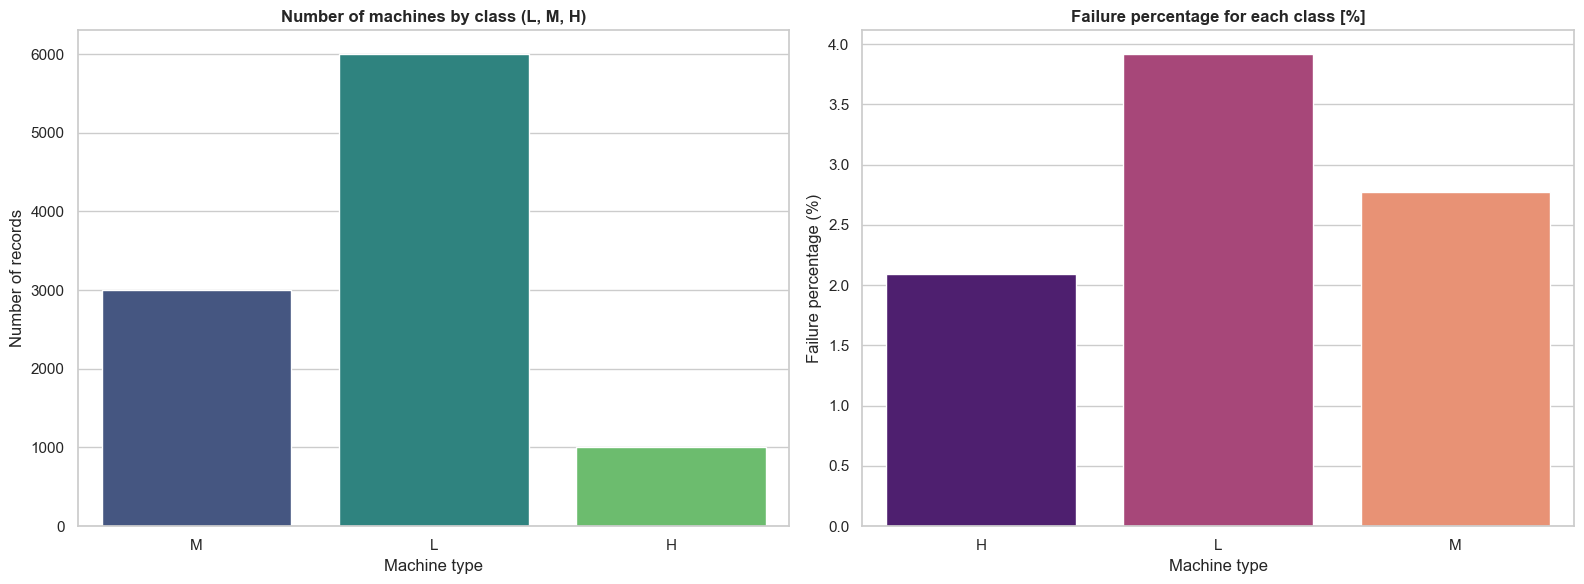

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='Type', ax=axes[0], palette='viridis', hue='Type', legend=False)
axes[0].set_title('Number of machines by class (L, M, H)', fontweight='bold')
axes[0].set_xlabel('Machine type')
axes[0].set_ylabel('Number of records')

failure_by_type = df.groupby('Type')['Target'].mean() * 100
sns.barplot(x=failure_by_type.index, y=failure_by_type.values, ax=axes[1], palette='magma', hue=failure_by_type.index, legend=False)
axes[1].set_title('Failure percentage for each class [%]', fontweight='bold')
axes[1].set_xlabel('Machine type')
axes[1].set_ylabel('Failure percentage (%)')

plt.tight_layout()
plt.show()